In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 共通パラメータ ----
ell   = 2.0 * np.pi   # ℓ = 2π
A     = 0.6
width = 1.0
k     = 3.0 / width
a     = np.arctanh(2.0/3.0)   # tanh(a) = 2/3

def beta_indices_and_c1(L, alphaR=0.71, epsilon=None):
    """
    L に対して、右側のターゲット j_R、左側の j_L、
    それらをちょうど ±1 にするための c1(L) を計算する補助関数。
    """
    if epsilon is None:
        epsilon = ell / L

    jh = int(L/3)             # 中央ブロックのインデックス
    jR = int(round(alphaR * L))  # 右側で |β|=1 を踏ませたい格子点
    jL = 3*jh - jR               # 左側で |β|=1 を踏ませたい格子点（条件 jL + jR = 3 jh）

    # 右側で β = ±1 になるように c1 を決める
    # k (jR - 2 jh - c1) epsilon = a  →  c1 = jR - 2 jh - a/(k epsilon)
    c1 = jR - 2*jh - a/(k*epsilon)

    return jh, jR, jL, c1, epsilon


def beta(j, L, pos, epsilon=None, alphaR=0.71):
    """
    元の beta(j, L, pos, epsilon) を拡張した版。
    - 右側の格子点 jR ≈ alphaR * L で lr/ur が |β|=1
    - 左側の格子点 jL = 3 jh - jR で ll/ul が |β|=1
    となるように、c1(L) を自動計算する。
    """
    jh, jR, jL, c1, eps = beta_indices_and_c1(L, alphaR=alphaR, epsilon=epsilon)

    if pos == "lr":
        # 右下
        return -A * np.tanh(k * (j - 2*jh - c1) * eps) - 0.6
    elif pos == "ur":
        # 右上
        return  A * np.tanh(k * (j - 2*jh - c1) * eps) + 0.6
    elif pos == "ll":
        # 左下
        return  A * np.tanh(k * (j -    jh + c1) * eps) - 0.6
    elif pos == "ul":
        # 左上
        return -A * np.tanh(k * (j -    jh + c1) * eps) + 0.6
    else:
        raise ValueError("pos must be 'lr', 'ur', 'll', or 'ul'")


In [4]:
# チェックしたい L のリスト
L_list = [60, 90, 120, 150, 1000]
poses  = ["lr", "ur", "ll", "ul"]

for L in L_list:
    jh, jR, jL, c1, eps = beta_indices_and_c1(L)
    print(f"===== L = {L} =====")
    print(f"  jh = {jh}, jR = {jR}, jL = {jL}, c1(L) = {c1:.6f}")

    for pos in poses:
        b_R = beta(jR, L, pos, epsilon=eps)   # 右側ターゲットでの β
        b_L = beta(jL, L, pos, epsilon=eps)   # 左側ターゲットでの β
        print(
            f"  pos={pos:2s}: "
            f"beta(jR) = {b_R:+.15f}, "
            f"beta(jL) = {b_L:+.15f}"
        )
    print()


===== L = 60 =====
  jh = 20, jR = 43, jL = 17, c1(L) = 0.438500
  pos=lr: beta(jR) = -1.000000000000000, beta(jL) = -0.000000482385268
  pos=ur: beta(jR) = +1.000000000000000, beta(jL) = +0.000000482385268
  pos=ll: beta(jR) = -0.000000482385268, beta(jL) = -1.000000000000000
  pos=ul: beta(jR) = +0.000000482385268, beta(jL) = +1.000000000000000

===== L = 90 =====
  jh = 30, jR = 64, jL = 26, c1(L) = 0.157750
  pos=lr: beta(jR) = -1.000000000000000, beta(jL) = -0.000000733349149
  pos=ur: beta(jR) = +1.000000000000000, beta(jL) = +0.000000733349149
  pos=ll: beta(jR) = -0.000000733349149, beta(jL) = -1.000000000000000
  pos=ul: beta(jR) = +0.000000733349149, beta(jL) = +1.000000000000000

===== L = 120 =====
  jh = 40, jR = 85, jL = 35, c1(L) = -0.123000
  pos=lr: beta(jR) = -1.000000000000000, beta(jL) = -0.000000904209684
  pos=ur: beta(jR) = +1.000000000000000, beta(jL) = +0.000000904209684
  pos=ll: beta(jR) = -0.000000904209684, beta(jL) = -1.000000000000000
  pos=ul: beta(jR) =

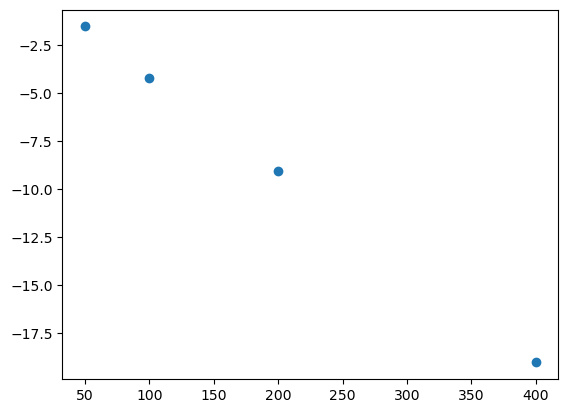

In [6]:
plt.plot([50,100,200,400],[-1.5480,-4.2369,-9.0818,-19.0121],'o')
plt.show()

In [1]:
int(0.7*500)

350

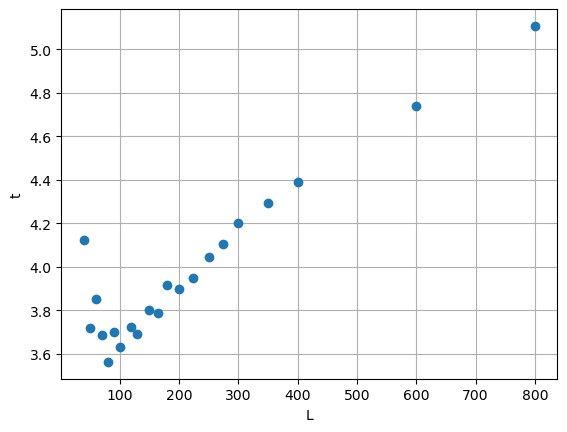

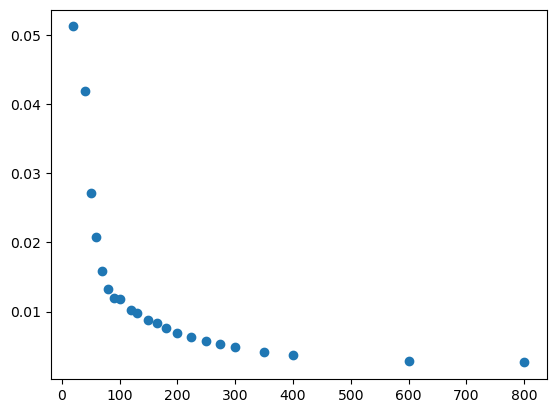

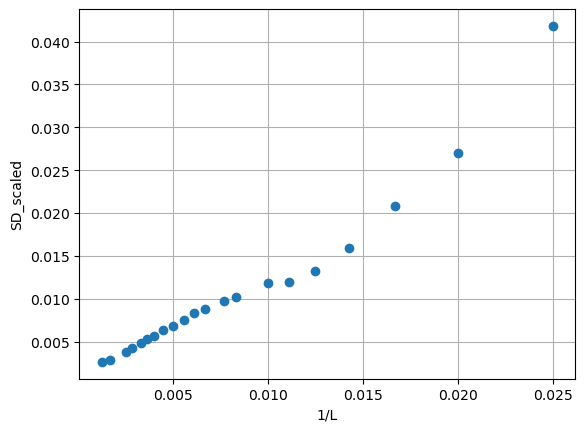

In [1]:
import numpy as np
import matplotlib.pyplot as plt
L = np.array([20,40,50,60,70,80,90,
              100,120,130,150,164,
              180,200,224,250,274,
              300,350,400,600,800])
sigma = L * 0.05
diff_sigma = np.array([0.024,-0.327,-1.147,-1.751,-2.389,-2.940,-3.428,
                       -3.818,-4.778,-5.233,-6.176,-6.828,
                       -7.64,-8.628,-9.775,-11.080,-12.237,
                       -13.549,-16.023,-18.497,-28.314,-37.891])
diff_sigma_scaled = (sigma + diff_sigma) / L
plt.plot(L[1:],[4.125,3.720,3.85,3.685,3.5625,3.699,
            3.630,3.725,3.692,3.8,3.786,
            3.916,3.9,3.95,4.044,4.105,
            4.2,4.294,4.388,4.74,5.107],"o")
plt.xlabel("L")
plt.ylabel("t")
plt.grid()
plt.show()
plt.plot(L,diff_sigma_scaled,"o")
plt.show()

plt.plot(1/L[1:], diff_sigma_scaled[1:], "o")
plt.xlabel("1/L")
#plt.xlim(0,0.01)
#plt.ylim(null,0.97)
plt.ylabel("SD_scaled")
plt.grid()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
L = np.array([100])
sigma = L * 0.05
diff_sigma = np.array([])
diff_sigma_scaled = (L + diff_sigma) / L
plt.plot(L[1:],[],"o")
plt.xlabel("L")
plt.ylabel("t")
plt.grid()
plt.show()
plt.plot(L,diff_sigma_scaled,"o")
plt.show()

plt.plot(1/L[1:], diff_sigma_scaled[1:], "o")
plt.xlabel("1/L")
#plt.xlim(0,0.01)
#plt.ylim(null,0.97)
plt.ylabel("SD_scaled")
plt.grid()
plt.show()